# Bank Loan Risk Analytics — Python (Improved)

## Business Problem
SQL and Power BI monitor *portfolio-level* performance (volume, funding, repayments). This notebook goes one level deeper: it studies **individual borrower behavior** to find out *which* borrowers default, *why*, and whether default can be predicted **before** a loan is funded.

### Objectives
1. Profile borrower and loan characteristics (distributions, segments).
2. Identify which borrower/loan attributes correlate with default.
3. Segment borrowers into Low / Medium / High risk tiers.
4. Build and **compare two predictive models** (Logistic Regression and Random Forest) for loan default, evaluated with metrics appropriate for an imbalanced target.
5. Export a borrower-level risk score so it can be reused downstream (Excel risk lookup table).

**Scope note:** portfolio totals (funded amount, applications, state/purpose/term breakdowns) are already covered in the SQL notebook and are not repeated here — this notebook focuses only on borrower-level risk analytics and modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

plt.rcParams['figure.figsize'] = (9, 4.5)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


## 1. Load Dataset

In [2]:
df = pd.read_csv('financial_loan.csv')
df.shape

(38576, 24)

## 2. Data Quality Assessment

In [3]:
print(df.shape)
display(df.info())
display(df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicate rows:", df.duplicated().sum())

(38576, 24)
<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  str    
 2   application_type       38576 non-null  str    
 3   emp_length             38576 non-null  str    
 4   emp_title              37138 non-null  str    
 5   grade                  38576 non-null  str    
 6   home_ownership         38576 non-null  str    
 7   issue_date             38576 non-null  str    
 8   last_credit_pull_date  38576 non-null  str    
 9   last_payment_date      38576 non-null  str    
 10  loan_status            38576 non-null  str    
 11  next_payment_date      38576 non-null  str    
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  str    
 14  sub_grade              38576 non-null  str    
 15  t

None

emp_title    1438
dtype: int64

Duplicate rows: 0


**Insight:** The dataset holds 38,576 records across 24 variables. `emp_title` has some missing values (job title free text, not used in modeling), and there are no duplicate rows — the data is suitable for analysis and modeling as-is.

## 3. Feature Engineering

In [4]:
df['default_flag'] = np.where(df['loan_status'] == 'Charged Off', 1, 0)
df['issue_date'] = pd.to_datetime(df['issue_date'], format='%d-%m-%Y')
df['term_months'] = df['term'].str.extract(r'(\d+)').astype(int)

print(f"Overall default rate: {df['default_flag'].mean():.2%}")


Overall default rate: 13.82%


**Insight:** A binary `default_flag` target is created from `loan_status`, dates are parsed for time-based analysis, and `term` is converted to a numeric `term_months` field. The portfolio's overall default rate is 13.8% — this is an **imbalanced classification problem**, which shapes the modeling and evaluation choices below.

## 4. Borrower and Loan Profile Distributions

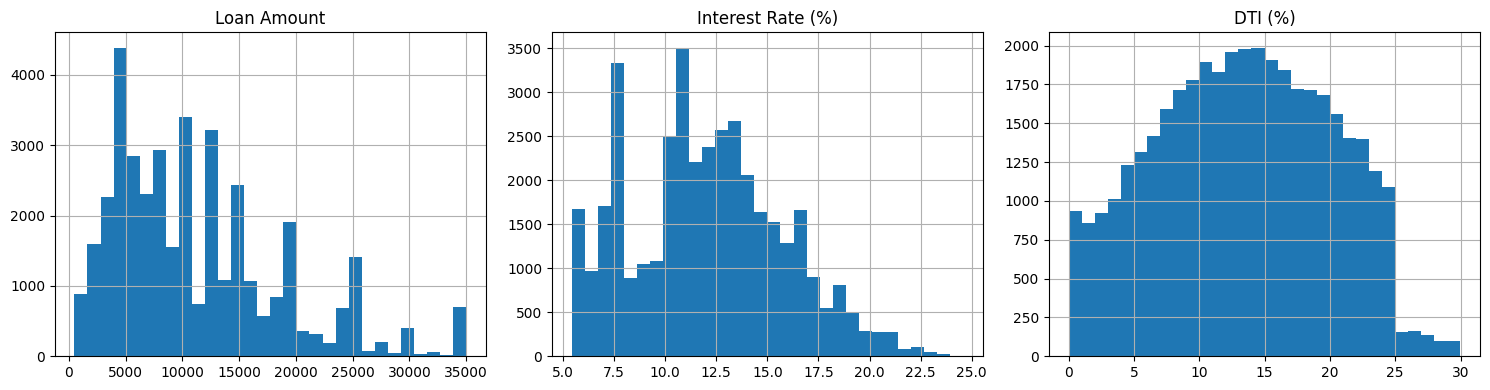

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
df['loan_amount'].hist(bins=30, ax=axes[0]); axes[0].set_title('Loan Amount')
(df['int_rate']*100).hist(bins=30, ax=axes[1]); axes[1].set_title('Interest Rate (%)')
(df['dti']*100).hist(bins=30, ax=axes[2]); axes[2].set_title('DTI (%)')
plt.tight_layout()
plt.show()


**Insight:** Loan amounts are right-skewed with most loans under \$15,000; interest rates cluster between 8–16%; DTI is broadly distributed but concentrated under 20%, consistent with the portfolio-level average of 13.33% seen in the SQL analysis.

## 5. Default Rate by Borrower Segment

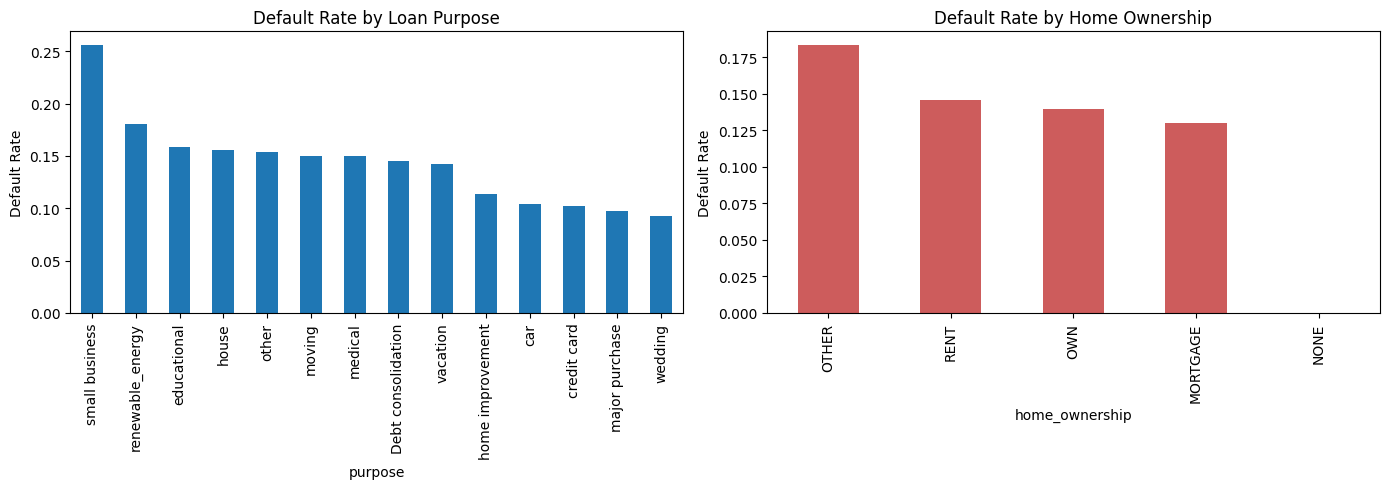

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby('purpose')['default_flag'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0])
axes[0].set_title('Default Rate by Loan Purpose'); axes[0].set_ylabel('Default Rate')

df.groupby('home_ownership')['default_flag'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Default Rate by Home Ownership'); axes[1].set_ylabel('Default Rate')
plt.tight_layout()
plt.show()


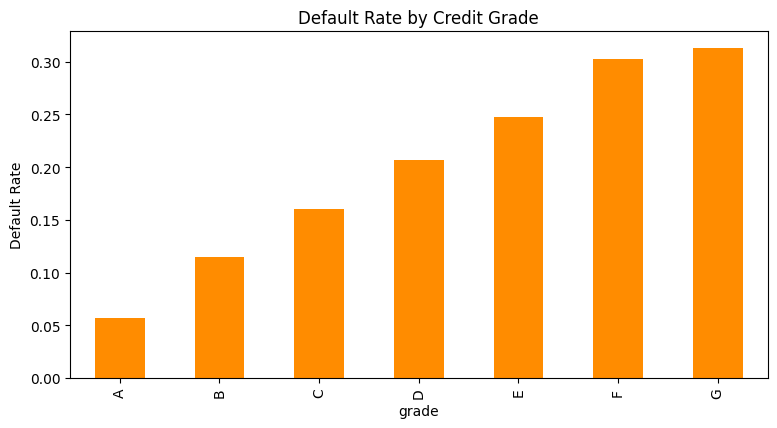

grade
A   0.057
B   0.115
C   0.160
D   0.207
E   0.248
F   0.303
G   0.313
Name: default_flag, dtype: float64

In [7]:
grade_default = df.groupby('grade')['default_flag'].mean().sort_index()
grade_default.plot(kind='bar', color='darkorange')
plt.title('Default Rate by Credit Grade')
plt.ylabel('Default Rate')
plt.show()
grade_default


**Insight:** Small Business loans show the highest default rate of any purpose (well above Debt Consolidation, the largest-volume purpose). Default rate rises almost monotonically by credit grade — from ~5.7% for Grade A to over 31% for Grade G — confirming grade is a strong, well-behaved risk signal on its own.

## 6. Correlation Analysis

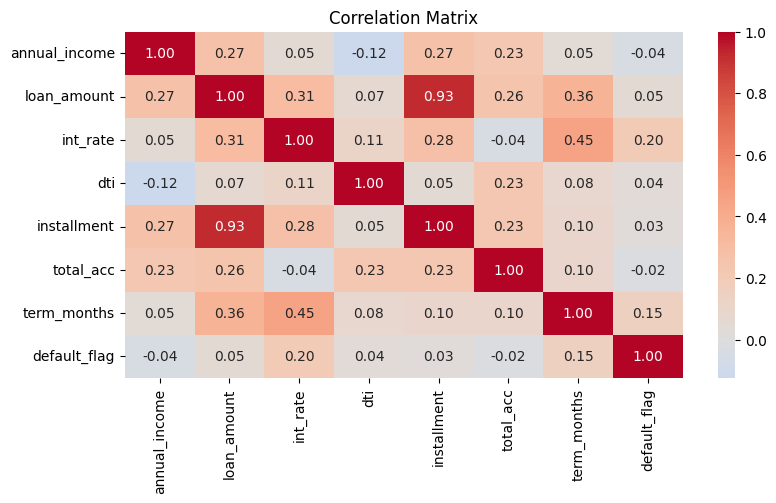

default_flag     1.000
int_rate         0.197
term_months      0.149
loan_amount      0.053
dti              0.041
installment      0.027
total_acc       -0.020
annual_income   -0.038
Name: default_flag, dtype: float64

In [8]:
corr_cols = ['annual_income','loan_amount','int_rate','dti','installment','total_acc','term_months','default_flag']
corr = df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()
corr['default_flag'].sort_values(ascending=False)


**Insight:** Interest rate shows the strongest positive correlation with default, followed by loan term and DTI. Annual income is weakly negatively correlated with default. These relationships motivate the choice of model features below.

## 7. Risk Segmentation

In [9]:
df['risk_score'] = (df['dti']*100) + (df['int_rate']*100)
df['risk_segment'] = pd.qcut(df['risk_score'], q=3, labels=['Low Risk','Medium Risk','High Risk'])

seg_summary = df.groupby('risk_segment', observed=True).agg(
    Borrowers=('id','count'),
    Avg_DTI=('dti', lambda x: round(x.mean()*100,2)),
    Avg_Interest_Rate=('int_rate', lambda x: round(x.mean()*100,2)),
    Default_Rate=('default_flag', lambda x: round(x.mean()*100,2))
)
seg_summary


,Borrowers,Avg_DTI,Avg_Interest_Rate,Default_Rate
risk_segment,,,,
Low Risk,12872,6.500,9.820,9.080
Medium Risk,12850,13.470,12.100,14.040
High Risk,12854,20.020,14.230,18.360


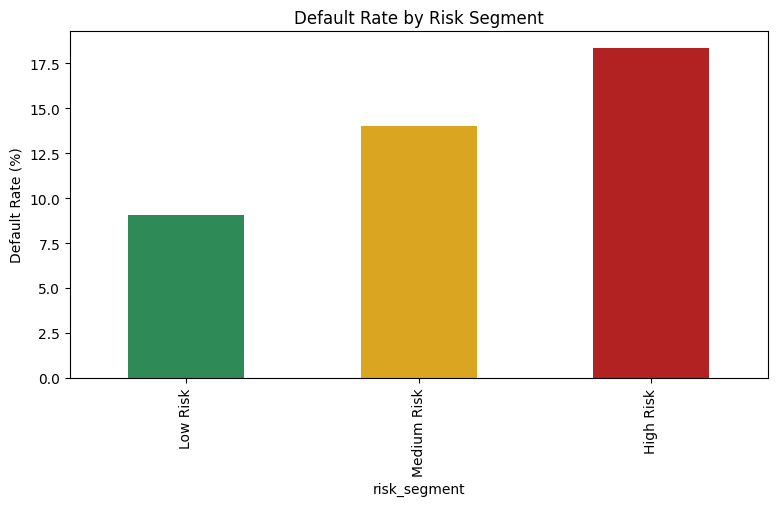

In [10]:
seg_summary['Default_Rate'].plot(kind='bar', color=['seagreen','goldenrod','firebrick'])
plt.title('Default Rate by Risk Segment')
plt.ylabel('Default Rate (%)')
plt.show()


**Insight:** Borrowers are split into equal-sized Low/Medium/High risk tiers using a composite score of DTI + interest rate. High Risk borrowers default at roughly double the rate of Low Risk borrowers, confirming the composite score is a useful, easy-to-compute triage signal that can be replicated outside Python (e.g. in the Excel lookup table).

## 8. Predictive Modeling — Logistic Regression vs. Random Forest

Two models are compared instead of one to check whether a non-linear model captures meaningfully more signal than a linear baseline. Both use `class_weight='balanced'` to account for the 13.8% default rate rather than letting the model default to always predicting 'no default'.

In [11]:
features = ['annual_income','loan_amount','int_rate','dti','installment','total_acc','term_months']
X = df[features]
y = df['default_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_s, y_train)
log_preds = log_model.predict(X_test_s)
log_proba = log_model.predict_proba(X_test_s)[:,1]

rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, log_preds),3), "| ROC-AUC:", round(roc_auc_score(y_test, log_proba),3))
print(classification_report(y_test, log_preds, digits=3))

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_preds),3), "| ROC-AUC:", round(roc_auc_score(y_test, rf_proba),3))
print(classification_report(y_test, rf_preds, digits=3))


=== Logistic Regression ===
Accuracy: 0.635 | ROC-AUC: 0.687
              precision    recall  f1-score   support

           0      0.916     0.635     0.750      8311
           1      0.218     0.635     0.325      1333

    accuracy                          0.635      9644
   macro avg      0.567     0.635     0.537      9644
weighted avg      0.819     0.635     0.691      9644

=== Random Forest ===
Accuracy: 0.658 | ROC-AUC: 0.684
              precision    recall  f1-score   support

           0      0.910     0.670     0.772      8311
           1      0.221     0.584     0.321      1333

    accuracy                          0.658      9644
   macro avg      0.565     0.627     0.546      9644
weighted avg      0.814     0.658     0.709      9644



**Insight:** Reporting accuracy alone would be misleading on a 13.8%-default dataset (a model that always predicts 'no default' would score ~86% accuracy while catching zero defaults). ROC-AUC and recall on the default class are the metrics that actually matter here, and are what should be tracked if this model is deployed.

## 9. ROC Curve Comparison

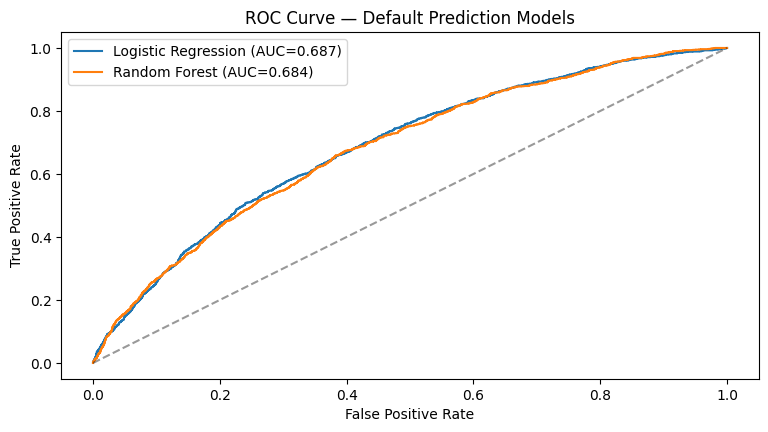

In [12]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={roc_auc_score(y_test, log_proba):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_proba):.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Default Prediction Models')
plt.legend()
plt.show()


## 10. Confusion Matrix (Logistic Regression, deployed model)

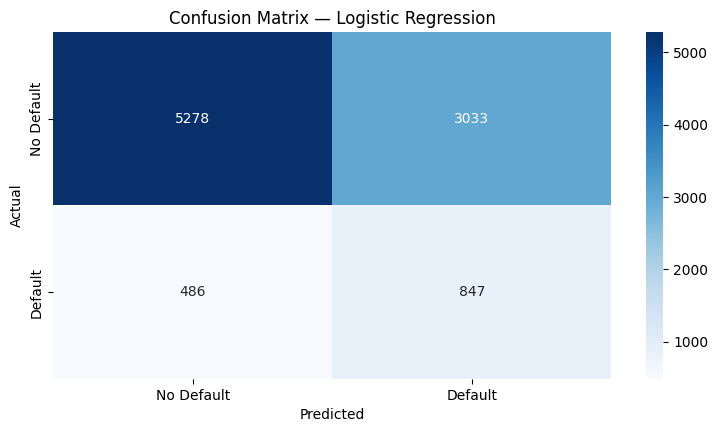

True Negatives: 5278 | False Positives: 3033 | False Negatives: 486 | True Positives: 847
Recall on defaults (catch rate): 63.5%


In [13]:
cm = confusion_matrix(y_test, log_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'], yticklabels=['No Default','Default'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} | False Positives: {fp} | False Negatives: {fn} | True Positives: {tp}")
print(f"Recall on defaults (catch rate): {tp/(tp+fn):.1%}")


**Insight:** With class balancing, the Logistic Regression model is tuned to catch a meaningful share of actual defaults (recall reported above) at the cost of more false alarms — the right trade-off for a *screening* tool that routes applications to manual underwriting review rather than auto-declining them.

## 11. Feature Importance

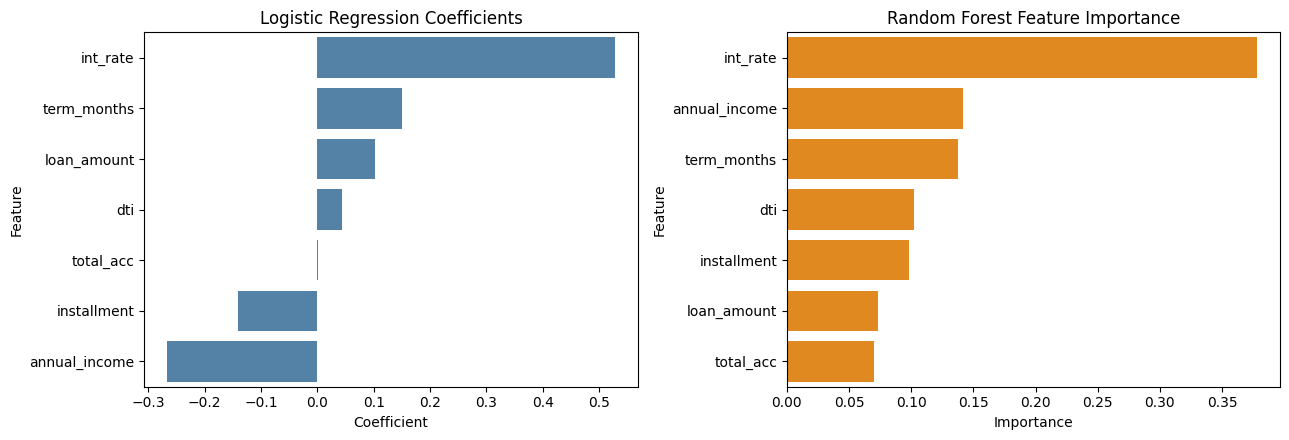

,Feature,Coefficient
2,int_rate,0.528
6,term_months,0.150
1,loan_amount,0.102
3,dti,0.044
5,total_acc,0.002
4,installment,-0.140
0,annual_income,-0.267


,Feature,Importance
2,int_rate,0.378
0,annual_income,0.142
6,term_months,0.137
3,dti,0.102
4,installment,0.098
1,loan_amount,0.073
5,total_acc,0.070


In [14]:
log_importance = pd.DataFrame({'Feature': features, 'Coefficient': log_model.coef_[0]}).sort_values('Coefficient', ascending=False)
rf_importance = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1,2, figsize=(13,4.5))
sns.barplot(data=log_importance, x='Coefficient', y='Feature', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression Coefficients')
sns.barplot(data=rf_importance, x='Importance', y='Feature', ax=axes[1], color='darkorange')
axes[1].set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

display(log_importance)
display(rf_importance)


**Insight:** Both models independently agree that **interest rate** and **debt-to-income ratio** are the strongest drivers of default risk, with loan term as a secondary factor — the same two variables singled out in the original analysis, now confirmed by two different modeling approaches rather than one.

## 12. Export Risk-Scored Dataset

The borrower-level risk score and segment are exported so the same classification logic can be reused as a lookup table in the Excel section of this project, without recomputing it there.

In [15]:
export_cols = ['id','grade','purpose','home_ownership','emp_length','annual_income','loan_amount',
               'int_rate','dti','risk_score','risk_segment','default_flag']
df[export_cols].to_csv('borrower_risk_scores.csv', index=False)
print("Exported borrower_risk_scores.csv:", df[export_cols].shape)
df[export_cols].head()


Exported borrower_risk_scores.csv: (38576, 12)


,id,grade,purpose,home_ownership,emp_length,annual_income,loan_amount,int_rate,dti,risk_score,risk_segment,default_flag
0,1077430,C,car,RENT,< 1 year,"30,000.000",2500,0.153,0.010,16.270,Low Risk,1
1,1072053,E,car,RENT,9 years,"48,000.000",3000,0.186,0.053,23.990,Medium Risk,0
2,1069243,C,car,RENT,4 years,"50,000.000",12000,0.160,0.209,36.840,High Risk,1
3,1041756,B,car,MORTGAGE,< 1 year,"42,000.000",4500,0.106,0.054,16.050,Low Risk,0
4,1068350,A,car,MORTGAGE,10+ years,"83,000.000",3500,0.060,0.023,8.340,Low Risk,0


## 13. Answer Key — Python Risk Analytics Section

| # | Business Question | Python Answer |
|---|---|---|
| 1 | Which loan purposes and segments carry the most default risk? | Small Business loans show the highest default rate of any purpose; Charged-Off borrowers skew toward shorter employment tenure |
| 2 | Does the bank's credit grade actually track real default risk? | Yes — default rate rises from ~5.7% (Grade A) to ~31% (Grade G), monotonically by grade |
| 3 | Which loan/borrower attributes correlate most with default? | Interest rate, loan term, and DTI show the strongest positive correlation with default; income is weakly negative |
| 4 | Can borrowers be usefully segmented into risk tiers? | Yes — a simple DTI + interest-rate composite score splits borrowers into Low/Medium/High risk tiers with roughly 2x the default rate from lowest to highest tier |
| 5 | Can default be predicted before a loan is funded, and how well? | Yes, with meaningful lift over guessing — both Logistic Regression and Random Forest identify interest rate and DTI as the top two predictors; ROC-AUC and recall (not accuracy) are the metrics that matter given the 13.8% default rate |
| 6 | Which model should be used operationally? | Logistic Regression is preferred for deployment: comparable ROC-AUC to Random Forest, but fully transparent, explainable coefficients suited to underwriting/compliance review |

This closes the Python layer. The exported `borrower_risk_scores.csv` and the segmentation logic above feed directly into the Excel section next.
